# Image Feature Extraction

### Overview of Feature Extraction

Feature extraction in computer vision refers to the process of distilling high-dimensional data into a set of numerically describable characteristics, commonly known as features. These features act as a summarized version of the entire data and make it easier to perform tasks like classification, object detection, image retrieval, and many more. The choice of features and their computation methods can significantly affect the performance and efficiency of the subsequent steps in a computer vision pipeline.

In essence, features should capture the important aspects of the data for the task at hand. They can be as simple as pixel values themselves or involve more complex computations like edges, corners, texture, and even object-level attributes.

---

### Summary of Feature Extraction Techniques Covered

#### 1. Harris Corner Detection

Corners are useful features as they are invariant to translation, rotation, and scale changes. Harris Corner Detection is one of the earliest and simplest corner detection algorithms. It works by computing a matrix M from gradient magnitudes and orientations and then calculating the response score R to find the corners.

#### 2. Laplacian-of-Gaussian (LoG) for Blob Detection

Blob detection aims to identify points in an image that differ in properties like intensity from surrounding regions. The Laplacian of Gaussian (LoG) method is used to find blobs at different scales and is particularly useful in tasks like object detection where the size of the object can vary.

#### 3. Histograms

While not traditionally considered as a feature extraction technique, histograms provide valuable insights into the distribution of pixel intensities or colors in an image and can be useful for tasks like image segmentation or thresholding.

#### 4. Histogram of Oriented Gradients (HoG)

HoG is primarily used for object detection, particularly for pedestrian detection in images. It captures the distribution and orientations of gradients in localized portions of an image, providing a robust descriptor for object detection.

#### 5. Scale Invariant Feature Transform (SIFT)

SIFT is used to detect and describe local features in images. The algorithm is robust to changes in scale, rotation, and translation. It has a variety of applications including object recognition, robotic mapping, and image stitching.


## Corner Detection

### Harris Corner Detection Algorithm

The Harris Corner Detection algorithm is used for detecting corners in images. Developed by Chris Harris and Mike Stephens in 1988, it remains a standard method for corner detection and is useful in various computer vision tasks.

#### How it Works:

1. **Compute Image Gradients**: Compute the image gradients $ I_x $ and $ I_y $ using derivative masks like Sobel filters.
   
2. **Compute Gradient Products**: For each pixel $ (x, y) $, compute products of gradients:
    - $ I_x^2 $
    - $ I_y^2 $
    - $ I_x \times I_y $
  
3. **Compute Harris Matrix**: For each pixel, form a 2x2 matrix $ M $ from the sum of gradient products within a window $ W $ around that pixel.
    $$
    M = \sum_{\text{window}} W(x,y) 
    \begin{pmatrix}
    I_x^2 & I_x I_y \\
    I_x I_y & I_y^2
    \end{pmatrix}
    $$

4. **Compute Corner Response**: Calculate the corner response $ R $ for each pixel using the determinant and trace of the Harris Matrix $ M $:
    $$
    R = \text{Det}(M) - k \times \text{Trace}(M)^2
    $$
    where $ \text{Det}(M) = \lambda_1 \times \lambda_2 $ and $ \text{Trace}(M) = \lambda_1 + \lambda_2 $, where $ \lambda_1 = I_x^2 $ and $ \lambda_2 = I_y^2 $ are the eigenvalues of $ M $.

5. **Thresholding and Non-Maximum Suppression**: Points where $ R $ exceeds a certain threshold and is also a local maximum are selected as corners.

#### Code Example: Implementing Harris Corner Detection from Scratch

In [16]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

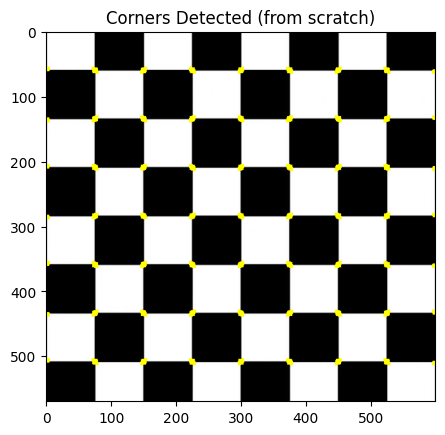

In [17]:
# Load a grayscale image
gray_image = cv2.imread('data/chessboard.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: Compute Image Gradients
I_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=5)
I_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=5)

# Step 2: Compute Gradient Products
Ixx = I_x**2
Iyy = I_y**2
Ixy = I_x*I_y

# Step 3 & 4: Compute Harris Matrix and Corner Response
window_size = 5
offset = window_size // 2
height, width = gray_image.shape
R = np.zeros((height, width))
k = 0.04

for y in range(offset, height-offset):
    for x in range(offset, width-offset):
        # Sum over a window
        Sxx = np.sum(Ixx[y-offset:y+offset+1, x-offset:x+offset+1])
        Syy = np.sum(Iyy[y-offset:y+offset+1, x-offset:x+offset+1])
        Sxy = np.sum(Ixy[y-offset:y+offset+1, x-offset:x+offset+1])
        
        # Compute Det and Trace of M
        det = (Sxx * Syy) - (Sxy**2)
        trace = Sxx + Syy
        
        # Compute Corner Response R
        R[y, x] = det - k*(trace**2)

# Step 5: Thresholding and Non-Maximum Suppression
R_max = np.max(R)
threshold = 0.01 * R_max

# Copy the image and convert it to color to draw corners on it
corner_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

for y in range(offset, height-offset):
    for x in range(offset, width-offset):
        if R[y, x] > threshold:
            corner_image[y-1:y+2, x-1:x+2, :] = [0, 255, 255]  # 3x3 square in yellow
            
plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.title('Corners Detected (from scratch)')
plt.show()


#### Code example: Using OpenCV's Implementation

Now, let's use OpenCV's built-in function to perform Harris Corner Detection.

The function `cv2.cornerHarris()` is used for Harris Corner Detection in OpenCV, and it takes several arguments:

### Parameters

1. **`img`**: The source image, in grayscale. The image should be float32 type.
  
2. **`blockSize`**: The size of the neighborhood considered for corner detection; usually, values like 2, 3, or 5 are used. This is the window size over which the summation of derivatives (which forms the matrix `M`) occurs.
  
3. **`ksize`**: Aperture parameter of the Sobel derivative used. This is the size of the Sobel kernel used to get the image derivatives. Typically, values like 3 or 5 are used.

4. **`k`**: Harris detector free parameter. Typically, values between 0.04 and 0.06 are used.

### Return Value

- **`dst`**: The output image that contains the Harris corner response values. It has the same size as the source image and a single channel, where each pixel value represents the "cornerness" measure. You can threshold this image to identify potential corners in the image.

Higher values in the `dst` array indicate areas of the image that are more likely to be corners. Typically, you would threshold these values to decide what should be considered a "corner" and what shouldn't be.

To visualize or process the corners, you can threshold the `dst` output and mark the positions where the corner response values exceed a certain threshold, as shown in the earlier code example.

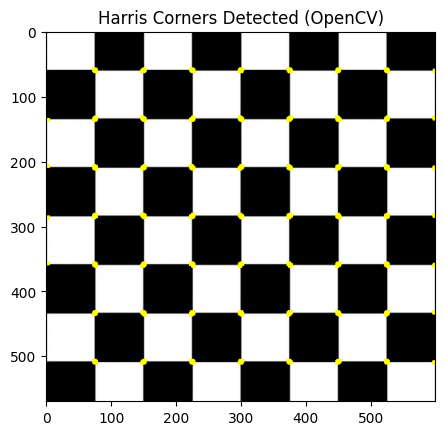

In [18]:
# Load the image (in grayscale)
img = cv2.imread('data/chessboard.jpg', 0)

# Convert to color for visualization
color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Perform Harris corner detection using OpenCV
dst = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)

# Threshold to locate the corners
thresh = 0.01 * dst.max()

# Mark the corners in a 3x3 yellow square
for y in range(dst.shape[0]):
    for x in range(dst.shape[1]):
        if dst[y, x] > thresh:
            color_img[y-3:y+3, x-3:x+3, :] = [0, 255, 255]

# Display the image using matplotlib
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners Detected (OpenCV)')
plt.show()

Let's see how corner detection works on the `church.jpg` image that we have used before for edge detection.

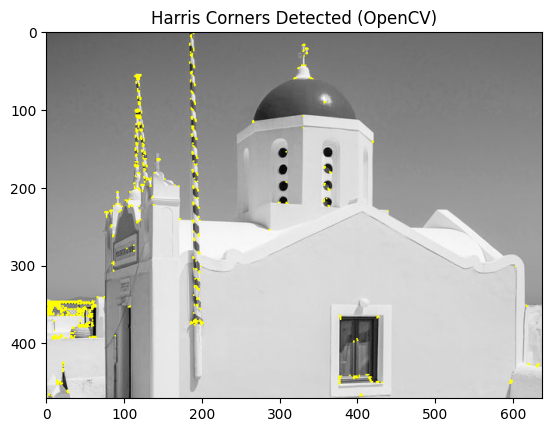

In [19]:
# Load the image (in grayscale)
img = cv2.imread('data/church.jpg', 0)

# Convert to color for visualization
color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Perform Harris corner detection using OpenCV
dst = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)

# Threshold to locate the corners
thresh = 0.01 * dst.max()

# Mark the corners in a 3x3 yellow square
for y in range(dst.shape[0]):
    for x in range(dst.shape[1]):
        if dst[y, x] > thresh:
            color_img[y-1:y+1, x-1:x+1, :] = [0, 255, 255]

# Display the image using matplotlib
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners Detected (OpenCV)')
plt.show()

## Multiscale 2D Blob Detection using Laplacian-of-Gaussian (LoG)

Blob detection aims to identify regions in an image that differ in properties like brightness or color compared to surrounding regions. In the context of computer vision, blobs usually represent regions of interest that one might want to analyze further.

The Laplacian-of-Gaussian (LoG) method is commonly used for blob detection. LoG is a two-step process involving the smoothing of an image with a Gaussian filter, followed by the application of the Laplacian filter. The LoG operator takes the second derivative of the image to find regions where there is a rapid change in intensity. It works well for identifying blobs of various sizes and shapes.

#### Mathematical Formulation:
$$ LoG(x, y) = - \frac{1}{\pi \sigma^4} \left[1 - \frac{x^2 + y^2}{2 \sigma^2} \right] e^{-\frac{x^2 + y^2}{2 \sigma^2}} $$

Here, $ \sigma $ is the standard deviation of the Gaussian.

#### Steps for Multiscale Blob Detection:

1. Generate the LoG kernel for different scales $ \sigma $.
2. Convolve the image with each LoG kernel.
3. Find local maxima in the response images to locate blobs.
4. Apply a threshold to remove low-response regions.

#### Code Example: OpenCV Implementation of Blob Detection

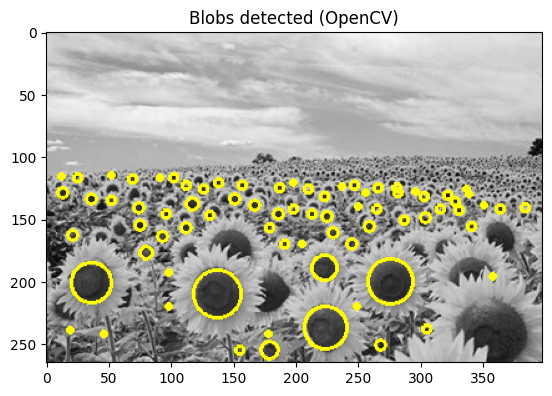

In [20]:
# Read image
img = cv2.imread('data/sunflowers.jpg', 0)

# Set up the detector with parameters
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 20  # Only detect blobs with area greater than 20 pixels
params.maxArea = 10000  # Only detect blobs with area smaller than 10000 pixels

detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(img) # List of detected blobs

# Draw detected blobs
out_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for k in keypoints:
    x, y = map(int, k.pt)   # Coordinates of the center of the blob mapped to integers
    diameter = k.size       # Diameter of blob
    cv2.circle(out_img, (x, y), int(diameter / 2), (0, 255, 255), 2)

plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.title('Blobs detected (OpenCV)')
plt.show()


#### Toy Example: Detecting and counting coins in an image

Small coins: 10
Medium coins: 3
Large coins: 2


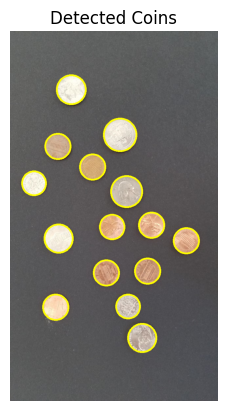

In [21]:
# Load the image
img = cv2.imread("data/coins.png", cv2.IMREAD_COLOR)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Invert the image to detect white blobs on dark background
gray_img = cv2.bitwise_not(gray_img)

# Apply GaussianBlur for better blob detection
blurred = cv2.GaussianBlur(gray_img, (7, 7), 0)

# Set up the blob detector parameters
params = cv2.SimpleBlobDetector_Params()

# Filter by Area
params.filterByArea = True
params.minArea = 3000
params.maxArea = 7000

# Create a blob detector object
detector = cv2.SimpleBlobDetector_create(params)

# Detect the blobs in the image
keypoints = detector.detect(blurred)

# Classify the keypoints based on size (diameter)
small_coins = []
medium_coins = []
large_coins = []

for k in keypoints:
    if k.size < 75:  
        small_coins.append(k)
    elif k.size < 85:  
        medium_coins.append(k)
    else:
        large_coins.append(k)

print(f"Small coins: {len(small_coins)}")
print(f"Medium coins: {len(medium_coins)}")
print(f"Large coins: {len(large_coins)}")

# Draw circles manually for better visualization
out_img = img.copy()
for k in keypoints:
    x, y = map(int, k.pt)
    radius = int(k.size // 2)
    cv2.circle(out_img, (x, y), radius, (0, 255, 255), 3)  # 3 is the thickness

# Show the result
plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Coins")
plt.axis("off")
plt.show()

## Histograms in Image Processing

In image processing, a histogram is a graphical representation that shows the distribution of pixel intensity levels in an image. The x-axis represents the intensity values (ranging from 0 to 255 for 8-bit images), while the y-axis represents the frequency or number of pixels with a particular intensity level. Histograms are useful for various tasks, such as image enhancement, segmentation, and feature extraction.

#### Types of Histograms

1. **Grayscale Histograms**: These histograms represent the distribution of pixel intensities in a grayscale image.
2. **Color Histograms**: These histograms represent the distribution of colors in an image. They can be calculated for each channel separately (e.g., Red, Green, and Blue for RGB images).
3. **Gradient Histograms**: These histograms represent the distribution of gradient orientations in an image. They are useful for tasks like object detection and image classification.

---

### Intensity Histogram (Grayscale Image)

Here is a code example to plot the histogram for a grayscale image using Python's Matplotlib library.

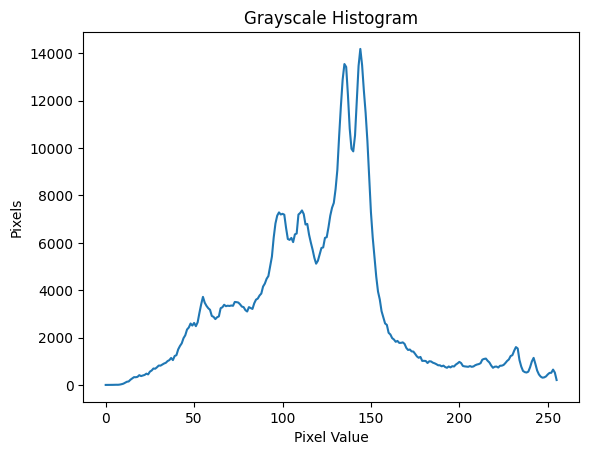

Histogram Feature Vector:
 [    0     0     1     2     3     6     7     6    15    31    53    95
   134   147   220   274   328   325   342   412   373   398   422   475
   445   561   609   693   684   746   818   814   860   904   934  1007
  1047  1139  1048  1221  1256  1501  1645  1756  1973  2096  2340  2424
  2593  2506  2617  2481  2643  3040  3406  3718  3473  3338  3239  3171
  2913  2874  2780  2857  2894  3239  3279  3385  3325  3345  3334  3353
  3341  3503  3495  3478  3403  3308  3285  3159  3099  3285  3248  3208
  3446  3600  3646  3775  3858  4154  4278  4480  4597  5008  5419  6217
  6818  7149  7284  7196  7225  7187  6630  6162  6124  6207  6030  6357
  6394  7193  7261  7367  7212  6772  6798  6345  6013  5713  5367  5119
  5242  5506  5782  5807  6208  6239  6660  7147  7480  7685  8266  9076
 10486 11763 12890 13549 13425 12223 10821  9970  9861 10533 11990 13465
 14187 13503 12424 11482 10298  8757  7289  6230  5424  4570  3941  3609
  3115  2856  2596  2535

In [22]:
# Read the image and convert it to grayscale
image = cv2.imread('data/tennis_court2.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate histogram
histogram, bin_edges = np.histogram(
    image, bins=256, range=(0, 255)
)

# Plot the histogram
plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Pixels")
plt.plot(histogram)
plt.show()

# Print the histogram values as a feature vector
print("Histogram Feature Vector:\n", histogram)

### Color Histogram (RGB Image)

Here's how to plot a color histogram for each channel (R, G, B):

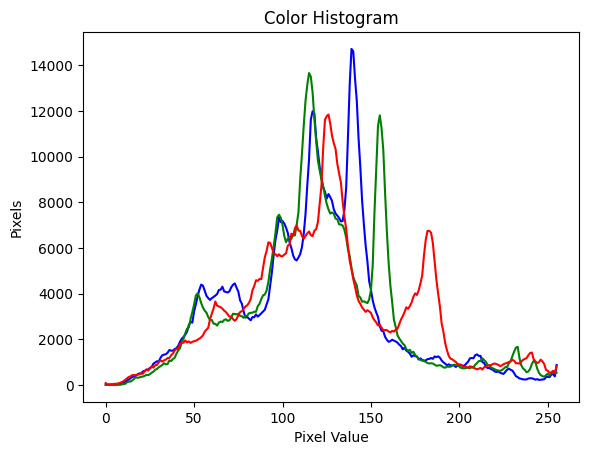

In [23]:
# Read the image
image = cv2.imread('data/tennis_court2.jpg')

# Separate the channels
channels = cv2.split(image)

colors = ('b', 'g', 'r')
plt.figure()
plt.title("Color Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Pixels")

# Loop for each channel
for channel, color in zip(channels, colors):
    histogram, bin_edges = np.histogram(
        channel, bins=256, range=(0, 255)
    )
    plt.plot(histogram, color=color)

plt.show()

## Histogram of Oriented Gradients (HOG)

The Histogram of Oriented Gradients (HOG) is a feature descriptor used primarily in computer vision and image processing for object detection. The idea behind HOG is that an object's local appearance and shape within an image can be described by the distribution of intensity gradients or edge directions.

Here are the basic steps for calculating HOG descriptors:

1. **Preprocessing**: Optionally apply some image normalization to improve the algorithm's resistance to lighting variations.

2. **Gradient Computation**: Compute the gradient of the image, usually in the x and y directions.

3. **Orientation Binning**: Divide the image into small cells (e.g., 8x8 pixels) and, for each cell, build a histogram of gradients.

4. **Block Normalization**: Group cells into larger blocks (e.g., 2x2 cells) and normalize the histogram for each block to compensate for changes in lighting and contrast.

5. **Descriptor Vector**: Flatten the histograms from each block into a single feature vector.

#### Code Example: HoG from Scratch
Here's a simple code example to compute HOG for a single cell of 8x8 pixels. This is just for demonstration; for real-world applications, you would extend this to cover multiple cells and blocks.

In [24]:
import numpy as np
import cv2
from skimage import exposure
from matplotlib import pyplot as plt

# Load and preprocess image
image = cv2.imread('data/texture_features.jpg', 0)
image = cv2.resize(image, (64, 128))

# Compute gradients
gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=1)
gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=1)

# Compute gradient magnitude and orientation
magnitude = np.sqrt(gx ** 2 + gy ** 2)
orientation = np.arctan2(gy, gx) * (180 / np.pi) % 180  # In degrees

# Create histogram of size 9 (9 bins for 180 degrees)
num_bins = 9
max_angle = 180
bin_width = max_angle // num_bins

hist = np.zeros(num_bins)
for angle, mag in zip(orientation.ravel(), magnitude.ravel()):
    bin = int(angle // bin_width)
    hist[bin] += mag

print("HOG feature for a single cell:", hist)


HOG feature for a single cell: [79280.08323192 24740.3764872  17234.35468779 12488.68405124
 18943.57688756 14153.47576804 18413.79949735 28644.19952893
 72308.99918558]


#### Code Example: HoG using OpenCV
OpenCV offers a more efficient and feature-rich implementation. Here is a sample code snippet:

In [25]:

# Read image
image = cv2.imread('data/texture_features.jpg', 0)
image = cv2.resize(image, (64, 128))

# Use OpenCV's HOG Descriptor
# cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)
hog = cv2.HOGDescriptor((64, 128), (16, 16), (8, 8), (8, 8), 9)
hog_descriptor = hog.compute(image)

print("HoG descriptor using OpenCV:", hog_descriptor)

HoG descriptor using OpenCV: [0.14996    0.22394653 0.2220365  ... 0.05306543 0.07582238 0.27939114]


### Applications of HoG: Pedestrian Detection

One classic and practical application where Histogram of Oriented Gradients (HoG) is commonly used is in pedestrian detection for automotive safety systems. Such systems use computer vision techniques to detect and warn of pedestrians crossing in front of a vehicle, thus reducing the risk of accidents.

#### Overview:

In a pedestrian detection system, the goal is to accurately and quickly identify human shapes within the frame captured by the car's camera. HoG descriptors can capture the edge or the gradient structure that forms the outline of a person, and these can be fed into a machine learning model to identify whether the shape is that of a pedestrian.

#### Process:

1. **Data Collection:** Gather or use a preexisting labeled dataset containing images of pedestrians and non-pedestrians.
2. **Feature Extraction:** Use the HoG descriptor to extract features from these images.
3. **Training:** Train a machine learning model (like a Support Vector Machine) using these features.
4. **Deployment:** In the real-world application, the car's onboard system would extract HoG features from regions of the image and use the trained model to determine whether each region contains a pedestrian.
5. **Action:** If a pedestrian is detected, the system could alert the driver or even take automated action, such as applying the brakes.

This is a simplified explanation, but it should give you an idea of how HoG can be applied in a real-world context.

## Scale Invariant Feature Transform (SIFT)

SIFT is an algorithm for detecting and describing local features in images. It was developed by David Lowe in 1999 and has found numerous applications in tasks such as object recognition, image stitching, and 3D reconstruction, among others. SIFT is particularly useful because it is both scale and rotation invariant, meaning it can identify features in images that are either resized or rotated.

#### Steps of the SIFT Algorithm:

1. **Scale-Space Extrema Detection**: The first step in SIFT is to identify potential keypoints by looking for points that are extrema (either maximum or minimum) in both scale and space. To do this, the image is convolved with Gaussian filters at different scales, and differences of Gaussians (DoG) are computed. Local maxima and minima of the DoG images across scales are detected as potential keypoints.

2. **Keypoint Localization**: The next step is to refine the location of keypoints. SIFT filters out low-contrast keypoints and edge keypoints to improve stability. It performs a detailed fit to the nearby data for location, scale, and ratio of principal curvatures. This helps in eliminating points that have low contrast or are poorly localized along an edge.

3. **Orientation Assignment**: For each keypoint, one or more orientations are computed based on the gradient directions in the keypoint's neighborhood. This ensures that the SIFT descriptor is rotation invariant.

4. **Keypoint Descriptor Calculation**: Finally, a descriptor is computed for each keypoint to summarize the gradient information in the keypoint's neighborhood. This descriptor is highly distinctive and partially invariant to other changes such as affine distortions.

5. **Keypoint Matching**: Finally, keypoints between different images can be matched by comparing their descriptors.

### SIFT with OpenCV - Code Example

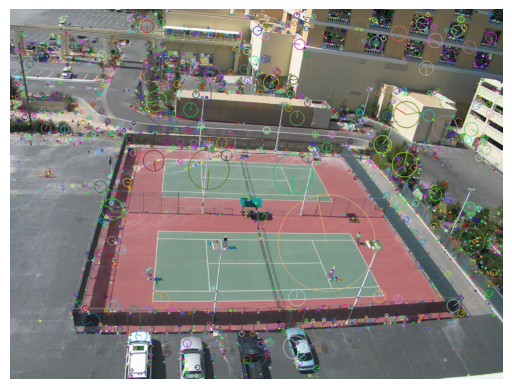

In [26]:
# Load the image
image = cv2.imread('data/tennis_court2.jpg')  # Make sure to load a grayscale image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Convert to grayscale for feature detection
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray_image, None)

# Draw keypoints on the color image
output_image = cv2.drawKeypoints(image_rgb, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints
plt.imshow(output_image)
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()


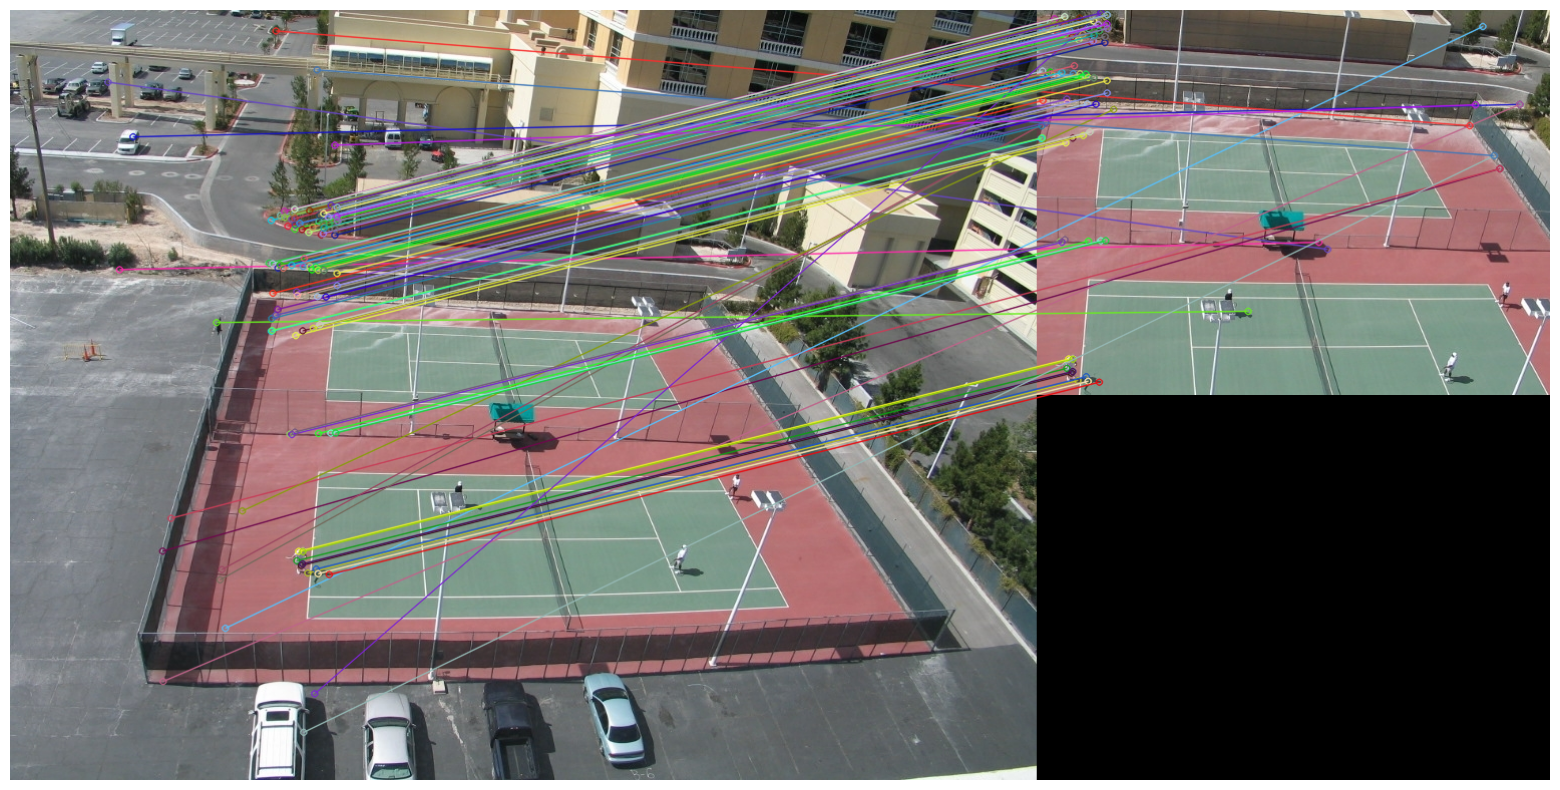

In [27]:
# Load the original image
original_image = cv2.imread('data/tennis_court2.jpg')

# Create a cropped version of the original image (roughly half the size)
height, width = original_image.shape[:2]
cropped_image = original_image[int(height*0.25):int(height*0.75), int(width*0.25):int(width*0.75)]

# Convert images to grayscale
gray_original = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
gray_cropped = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray_original, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray_cropped, None)

# Use BFMatcher to find the best matches between descriptors
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test to find good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Limit the number of matches displayed
num_matches_to_show = 100
if len(good_matches) > num_matches_to_show:
    good_matches = good_matches[:num_matches_to_show]

# Draw matches
img_matches = cv2.drawMatches(original_image, keypoints1, cropped_image, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Convert to RGB for displaying via matplotlib
img_matches = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)

# Display the matches
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()